In [207]:
'''
Names: Prashant Ram, Muhammad Hassan
Course: CSC 177
Assignment: 2 - Linear Regression
Professor: Jagannadha Chidella
Details: This project deals with preprocessing data from a .csv file to ready it for
        data modelling and then using linear regression to test the model.
'''

import pandas
import matplotlib.pyplot as matPlot
import seaborn
import numpy
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split



In [208]:
'''
This block reads the data from a .csv file and makes columns for the data
'''
try:
    # import the data from the .csv file. "data" = dataframe. Our data is using ; as a separator and quotes to enclose
    # the data. The first row is the header row so we use the correct separator and quote character or else pandas treats these
    # data as a single column which we don't want.
    data = pandas.read_csv('loan_data.csv')

    #print the data attribute columns
    print(data.columns)
        
    # print the number of rows and columns
    print(f'We have {data.shape[0]} rows')
    print(f'We have {data.shape[1]} columns')

    # print the first 5 rows of the data
    print('\n', data.head())
        
except Exception as e:
    print("An error occured while trying to read from the CSV file", e)

Index(['Text', 'Income', 'Credit_Score', 'Loan_Amount', 'DTI_Ratio',
       'Employment_Status', 'Approval'],
      dtype='object')
We have 24000 rows
We have 7 columns

                                                 Text  Income  Credit_Score  \
0  I need a loan to pay for an international vaca...   26556           581   
1  I want to make home improvements like installi...  197392           389   
2  I need a loan for home renovation, including a...   44561           523   
3  I need funds to buy new furniture and applianc...  190363           729   
4           I need a loan to start a small business.   61853           732   

   Loan_Amount  DTI_Ratio Employment_Status  Approval  
0         8314      79.26          employed  Rejected  
1       111604      22.14          employed  Rejected  
2        34118      45.44          employed  Rejected  
3       118757      10.22        unemployed  Rejected  
4        19210      44.13          employed  Approved  


In [209]:
'''
This block counts the number of missing values in each column
'''

#list to hold the columns with missing values
missingColumns = []

#our original number of rows with unclean data
original_rows = data.shape[0]

try:
    #loop through the columns and get the number of missing values
    for i in data.columns:
        #get the total of column of missing values
        total = data[i].isnull().sum()
        #display the column and the missing values number
        print(f"{i}: {total}")

        #add missing value columns to the list
        if total > 0:
            missingColumns.append(i)

    #finally display which columns had missing values
    if len(missingColumns) == 0:
        print("\nThere were no missing values in the data set.")
    else:
        #display the columns with missing values
        print(f"\nThese columns had missing data: {missingColumns}")
    
#catch any reading errors
except Exception as e:
    print("umm. An error occurred while trying to count the missing values..", e)

Text: 0
Income: 0
Credit_Score: 0
Loan_Amount: 0
DTI_Ratio: 0
Employment_Status: 0
Approval: 0

There were no missing values in the data set.


In [210]:
'''
This block drops all rows and columns with missing data
'''
# print the number of rows and columns
original_rows = data.shape[0]
original_columns = data.shape[1]
print(f'We have {original_rows} [original] rows and {original_columns} columns')
print('\nOriginal Data:', data.head())
    
#drops all rows with no data
data = data.dropna()

clean_rows = data.shape[0]
clean_columns = data.shape[1]
print(f'\nWe have {clean_rows} [Clean] rows and {clean_columns} columns')
print('\nCleaned data Data:', data.head())

print(f'\n\nWe had {original_rows - clean_rows} rows and {original_columns - clean_columns} columns of missing data')

We have 24000 [original] rows and 7 columns

Original Data:                                                 Text  Income  Credit_Score  \
0  I need a loan to pay for an international vaca...   26556           581   
1  I want to make home improvements like installi...  197392           389   
2  I need a loan for home renovation, including a...   44561           523   
3  I need funds to buy new furniture and applianc...  190363           729   
4           I need a loan to start a small business.   61853           732   

   Loan_Amount  DTI_Ratio Employment_Status  Approval  
0         8314      79.26          employed  Rejected  
1       111604      22.14          employed  Rejected  
2        34118      45.44          employed  Rejected  
3       118757      10.22        unemployed  Rejected  
4        19210      44.13          employed  Approved  

We have 24000 [Clean] rows and 7 columns

Cleaned data Data:                                                 Text  Income  Credit_Scor

In [211]:
'''This block checks for duplicate rows and drops the ones that are duplicates'''
total_duplicates = data.duplicated().sum()

if total_duplicates != 0:
    data = data.drop_duplicates(inkeep='first')
    print(f"\nThere were {total_duplicates} duplicate rows in the data set.")
else:
    print("\nThere were no duplicate rows in the data set.")



There were no duplicate rows in the data set.


In [212]:
'''
All the data columns are numerical so we do not need to do any conversion from categorical to numerical data. To verfiy, we will
print out the data types.
'''
print(data.dtypes)

Text                  object
Income                 int64
Credit_Score           int64
Loan_Amount            int64
DTI_Ratio            float64
Employment_Status     object
Approval              object
dtype: object


In [213]:
'''This codes will remove any outliers in the data using z-score method. Out threshold is 3.0. Any data point with a z-score greater than 3.0 will 
be removed.'''

columns = data.select_dtypes(include=['float64', 'int64']).columns
with_outliers = data

#run this 5 times because for some reason it's unable to remove all the outliers in 3 loops.
for i in range(0, 5):
    for col in columns:
        Q1 = with_outliers[col].quantile(0.25)    
        Q3 = with_outliers[col].quantile(0.75)     
        IQR = Q3 - Q1                         
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        with_outliers= with_outliers[(with_outliers[col] >= lower_bound) & (with_outliers[col] <= upper_bound)]
        data = with_outliers

print("Original dataset with outliers:", original_rows)
print("Cleaned dataset without outliers:", with_outliers.shape[0])
print("Number of rows with outliers removed:", original_rows - with_outliers.shape[0])


Original dataset with outliers: 24000
Cleaned dataset without outliers: 20624
Number of rows with outliers removed: 3376


In [214]:
'''This block converts all the categorical data to numerical data using one-hot encoding.'''

data['Employment_Status'] = data['Employment_Status'].replace({'employed': 1, 'unemployed': 0}).infer_objects(copy=False)
data['Approval'] = data['Approval'].replace({'Approved': 1, 'Rejected': 0}).infer_objects(copy=False)

C:\Users\rampr\AppData\Local\Temp\ipykernel_37268\638651646.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Employment_Status'] = data['Employment_Status'].replace({'employed': 1, 'unemployed': 0}).infer_objects(copy=False)
C:\Users\rampr\AppData\Local\Temp\ipykernel_37268\638651646.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Approval'] = data['Approval'].replace({'Approved': 1, 'Rejected': 0}).infer_objects(copy=False)


In [215]:
'''Save the cleaned dataset to a new csv file. This will be used for the linear regression model.'''
try:
    data.to_csv('cleaned_loan_data.csv', index=False)
    print("Cleaned data saved to current directory as file name = cleaned_loan_data.csv")
except Exception as e:
    print("An error occurred while trying to save the cleaned data to a CSV file", e)

An error occurred while trying to save the cleaned data to a CSV file [Errno 13] Permission denied: 'cleaned_loan_data.csv'


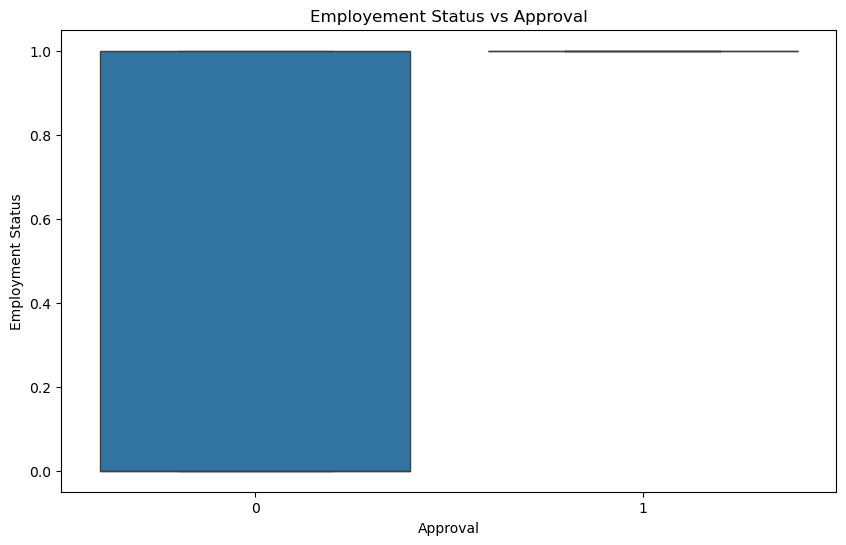

In [216]:
'''
This block plots the Sugar columns with the Quality column.
'''
#plot the data
matPlot.figure(figsize=(10, 6))
seaborn.boxplot(x='Approval', y='Employment_Status', data=data)
matPlot.title('Employement Status vs Approval')
matPlot.xlabel('Approval')
matPlot.ylabel('Employment Status')
matPlot.show()

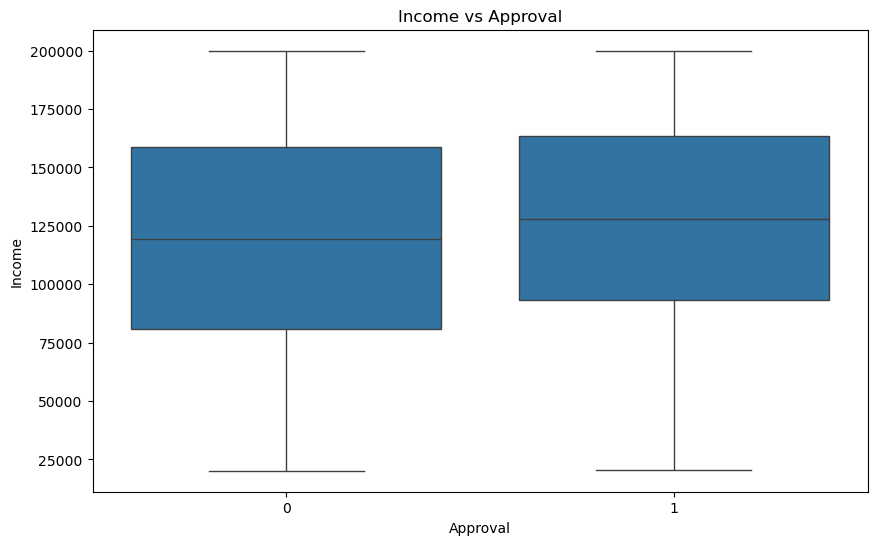

In [217]:
'''
This block plots the Sugar columns with the Quality column.
'''
#plot the data
matPlot.figure(figsize=(10, 6))
seaborn.boxplot(x='Approval', y='Income', data=data)
matPlot.title('Income vs Approval')
matPlot.xlabel('Approval')
matPlot.ylabel('Income')
matPlot.show()

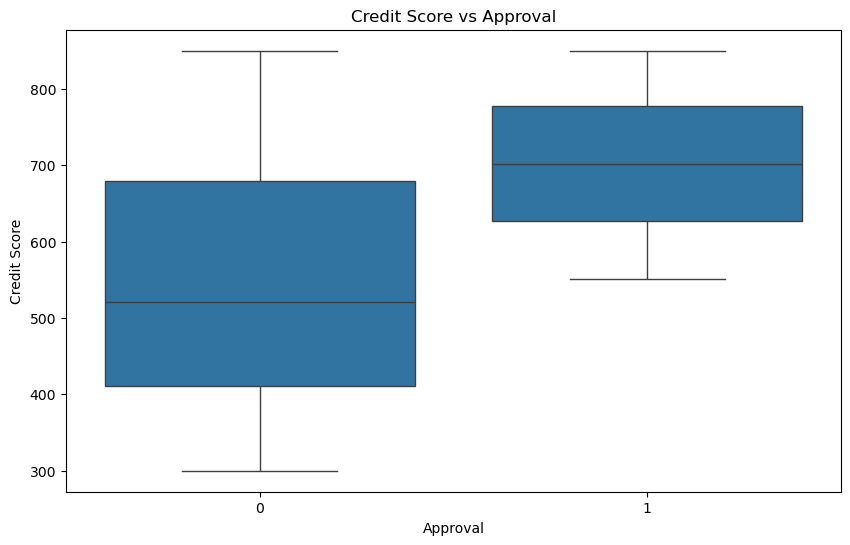

In [218]:
'''
This block plots the Sugar columns with the Quality column.
'''
#plot the data
matPlot.figure(figsize=(10, 6))
seaborn.boxplot(x='Approval', y='Credit_Score', data=data)
matPlot.title('Credit Score vs Approval')
matPlot.xlabel('Approval')
matPlot.ylabel('Credit Score')
matPlot.show()

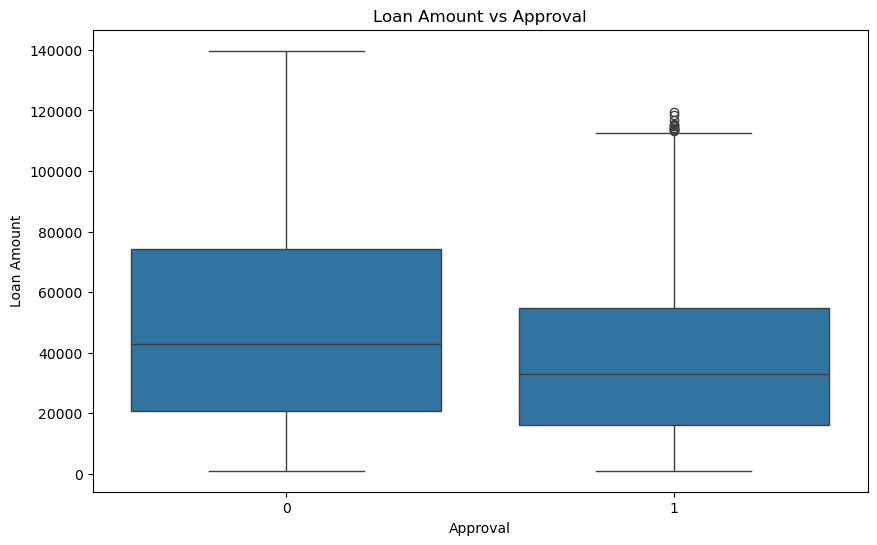

In [219]:
'''
This block plots the Sugar columns with the Quality column.
'''
#plot the data
matPlot.figure(figsize=(10, 6))
seaborn.boxplot(x='Approval', y='Loan_Amount', data=data)
matPlot.title('Loan Amount vs Approval')
matPlot.xlabel('Approval')
matPlot.ylabel('Loan Amount')
matPlot.show()

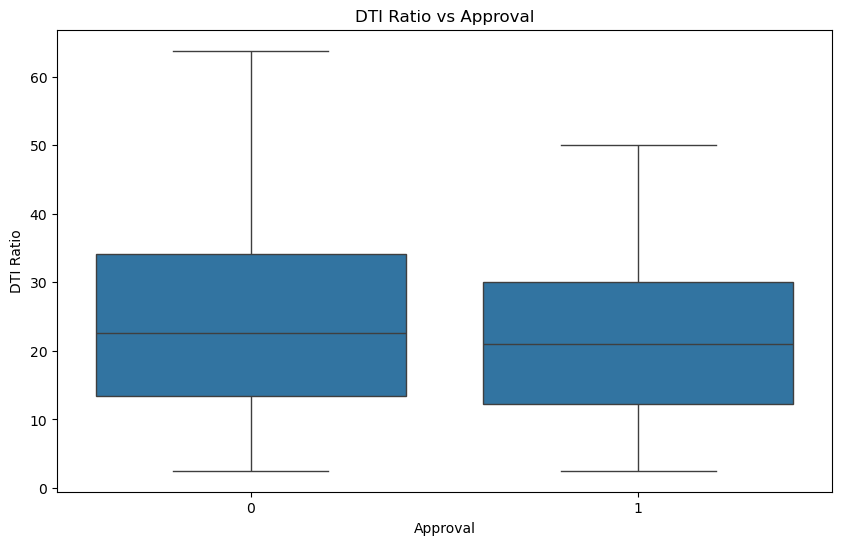

In [220]:
matPlot.figure(figsize=(10, 6))
seaborn.boxplot(x='Approval', y='DTI_Ratio', data=data)
matPlot.title('DTI Ratio vs Approval')
matPlot.xlabel('Approval')
matPlot.ylabel('DTI Ratio')
matPlot.show()

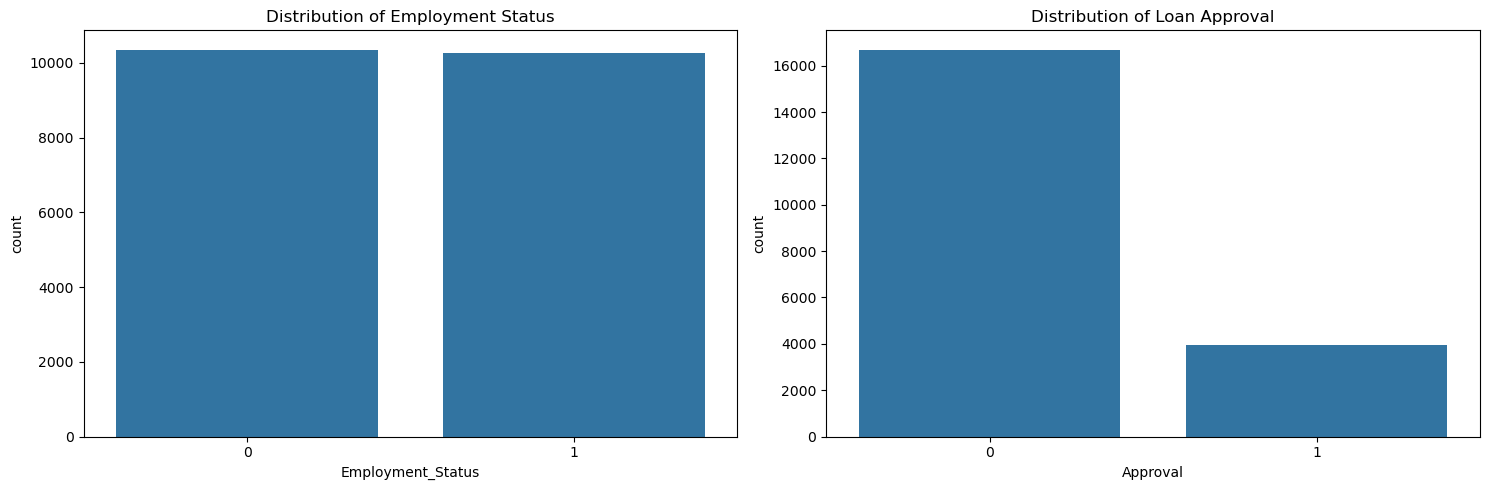

In [221]:
matPlot.figure(figsize=(15, 5))
matPlot.subplot(1, 2, 1)
seaborn.countplot(x='Employment_Status', data=data)
matPlot.title('Distribution of Employment Status')

matPlot.subplot(1, 2, 2)
seaborn.countplot(x='Approval', data=data)
matPlot.title('Distribution of Loan Approval')

matPlot.tight_layout()
matPlot.show()

In [222]:
'''This block balances the datase because currently, we have about 80% of it leaning towards 'rejected, i.e., 0' which heavily skews the data.'''

rejected = data[data["Approval"] == 0 ]
approved = data[data["Approval"] == 1]

# downsample the rejected results to match the approved class size
rejected_downsampled = rejected.sample(n=len(approved), random_state=42)

# combine the samples into 1 dataset
data = pandas.concat([rejected_downsampled, approved])

# Check the new class distribution
print("\nBalanced Class Distribution (Downsampling):")
# df_balanced["Approval"].value_counts()


Balanced Class Distribution (Downsampling):


In [223]:
'''
This block splits the cleaned dataset into training and testing data.
'''
from sklearn.discriminant_analysis import StandardScaler
from sklearn.model_selection import train_test_split

#display what should be the expected data modelling pre-split into training and testing data sets.
total_rows = data.shape[0]
training_data = int(0.8 * total_rows)
print(f'We have a total of {total_rows} rows of data.')
print(f'80% of {total_rows} is {training_data} which should be our testing data')
print(f'Training would be {total_rows - training_data}')

# the are our features and target variables (we exclude "Gender" column as it serves no purpose here)
features = data[['Income', 'Credit_Score', 'Loan_Amount', 'DTI_Ratio', 'Employment_Status']].values
target = data['Approval'].values

#splits the data 80 (training) and 20 (testing)
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.20, random_state=42, shuffle=True)

#showing the results of the split
print('\nRESULTS OF SPLIT')
print(f'Training set shape details are: x_train = {x_train.shape}, y_train= {y_train.shape}')
print(f'Testing set shape details are: x_test = {x_test.shape}, y_train= {y_test.shape}')

#Printing the data for the first 5 rows for both training and test datasets
print("\n--- Training Set Statistics ---")
print(x_train)  # Display the first 5 rows of the training set

print("\n--- Test Set Statistics ---")
print(x_test)  # Display the first 5 rows of the test set


We have a total of 7866 rows of data.
80% of 7866 is 6292 which should be our testing data
Training would be 1574

RESULTS OF SPLIT
Training set shape details are: x_train = (6292, 5), y_train= (6292,)
Testing set shape details are: x_test = (1574, 5), y_train= (1574,)

--- Training Set Statistics ---
[[1.80720e+05 8.49000e+02 1.32275e+05 5.75000e+00 0.00000e+00]
 [9.02230e+04 8.21000e+02 9.19000e+03 4.99900e+01 1.00000e+00]
 [6.46850e+04 5.86000e+02 2.57360e+04 4.31900e+01 1.00000e+00]
 ...
 [8.32850e+04 3.83000e+02 4.41650e+04 2.05900e+01 0.00000e+00]
 [1.64519e+05 5.99000e+02 4.57780e+04 2.73900e+01 1.00000e+00]
 [1.42938e+05 6.24000e+02 2.48300e+03 1.65500e+01 1.00000e+00]]

--- Test Set Statistics ---
[[6.70590e+04 6.27000e+02 2.28290e+04 1.68200e+01 1.00000e+00]
 [1.90067e+05 7.14000e+02 8.00440e+04 9.43000e+00 1.00000e+00]
 [1.44109e+05 5.18000e+02 8.47770e+04 1.88800e+01 1.00000e+00]
 ...
 [9.48470e+04 8.38000e+02 3.69950e+04 6.37000e+00 1.00000e+00]
 [1.53212e+05 5.30000e+02 3

In [224]:
# We calculate the meana nd stanard deviation for the training and test data to compare the model's results
train_mean = x_train.mean()
train_std = x_train.std()

test_mean = x_test.mean()
test_std = x_test.std()

# we display the mean and standard deviation to see if the results match.
print(f'The mean for the training data is {train_mean} and the standard deviation is {train_std}')
print(f'The mean for the testing data is {test_mean} and the standard deviation is {test_std}')

The mean for the training data is 33326.60257660521 and the standard deviation is 53705.25745370224
The mean for the testing data is 33482.555667090215 and the standard deviation is 53996.87421169361


In [225]:
# This is the start of assignment 2

In [226]:
# Part (a) - Regression

The Root Mean Square Error = 0.3810
The R-squared = 0.4191


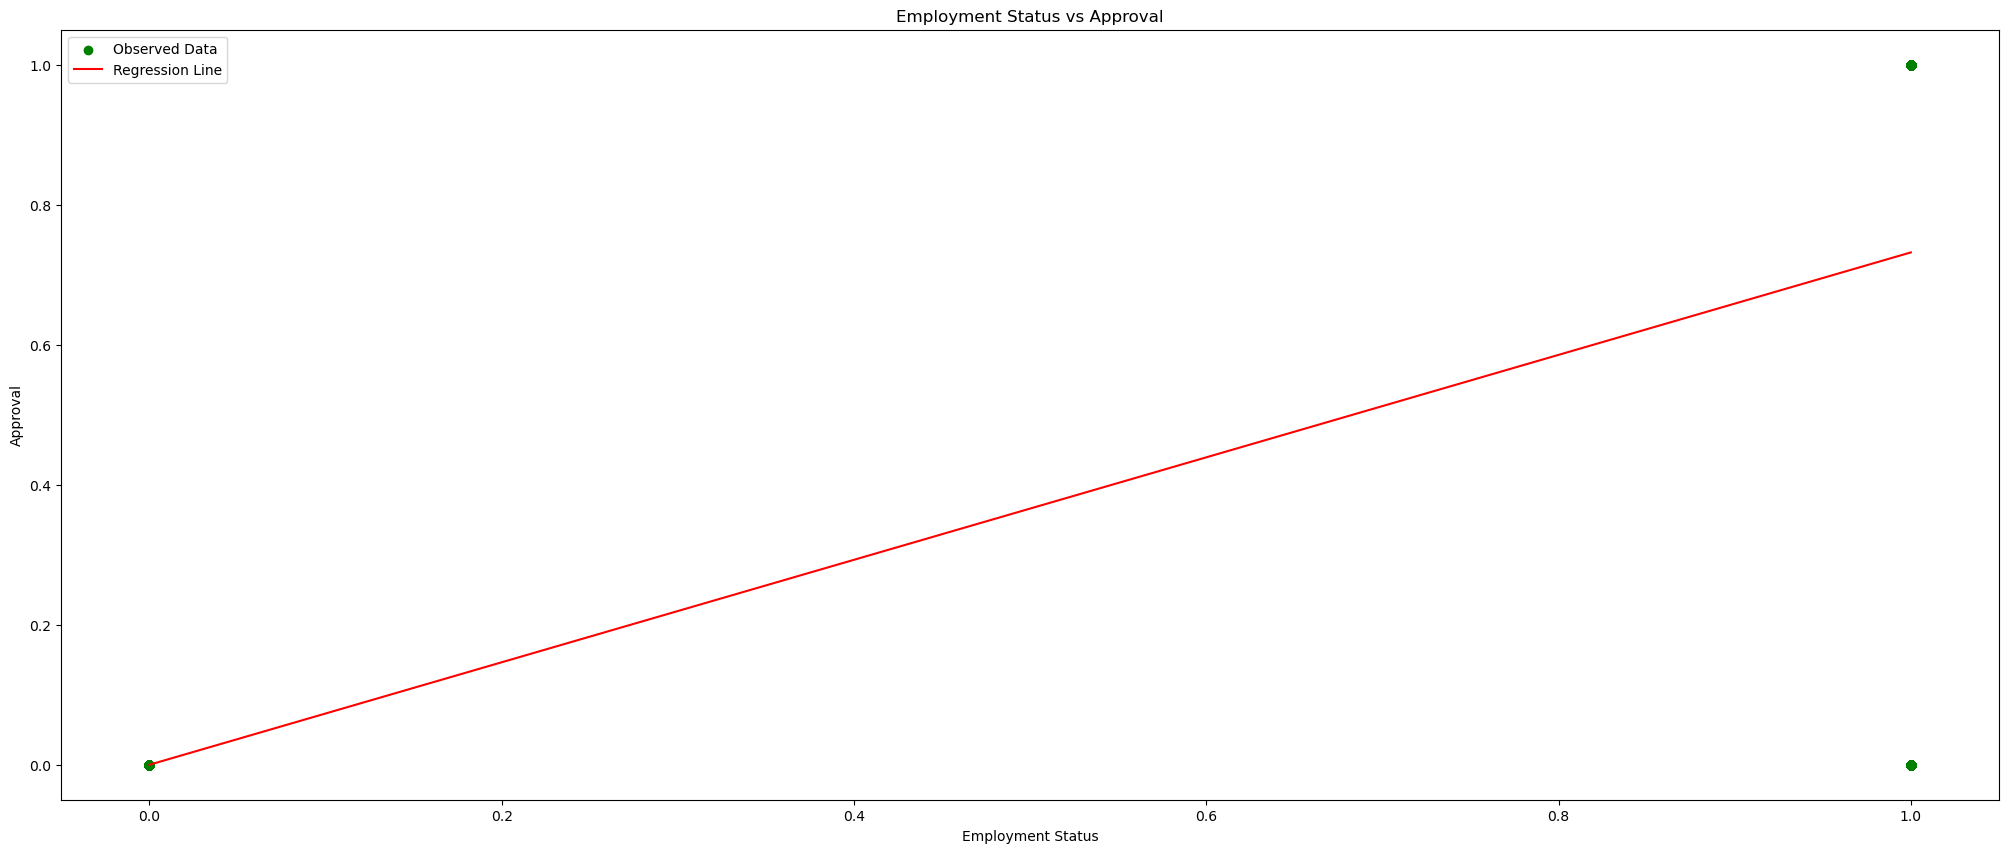

In [234]:
'''This block creates a linear regression model for Employment Status feature against Approval target'''
x = data['Employment_Status'].values.reshape(-1, 1)  
y = data['Approval'].values

#splitting the dataset into training and test sets (80% train, 20% test)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

#create a single linear regression model object
single_regression = LinearRegression()

#fit the model to the training data
single_regression.fit(x_train, y_train)

#apply the model to the test data to get predictions
y_predicted_single = single_regression.predict(x_test)

#model evaluation using RMSE and R-squared
r = numpy.sqrt(mean_squared_error(y_test, y_predicted_single))
r_squared_score = r2_score(y_test, y_predicted_single)

print('The Root Mean Square Error = %.4f' % r)
print('The R-squared = %.4f' % r_squared_score)

#we need to sort x_test and the predicted values for a smooth regression line.
sorted_idx = numpy.argsort(x_test.ravel())
x_test_sorted = x_test[sorted_idx]
y_pred_sorted = y_predicted_single[sorted_idx]

#plot the test data as a scatter plot
matPlot.figure(figsize=(25, 10))
matPlot.scatter(x_test, y_test, color='green', label='Observed Data')
#plot the regression line
matPlot.plot(x_test_sorted, y_pred_sorted, color='red', label='Regression Line')
matPlot.title('Employment Status vs Approval')
matPlot.xlabel('Employment Status')
matPlot.ylabel('Approval')
matPlot.legend()
matPlot.show()

The Root Mean Square Error = 0.4187
The R-squared = 0.2986


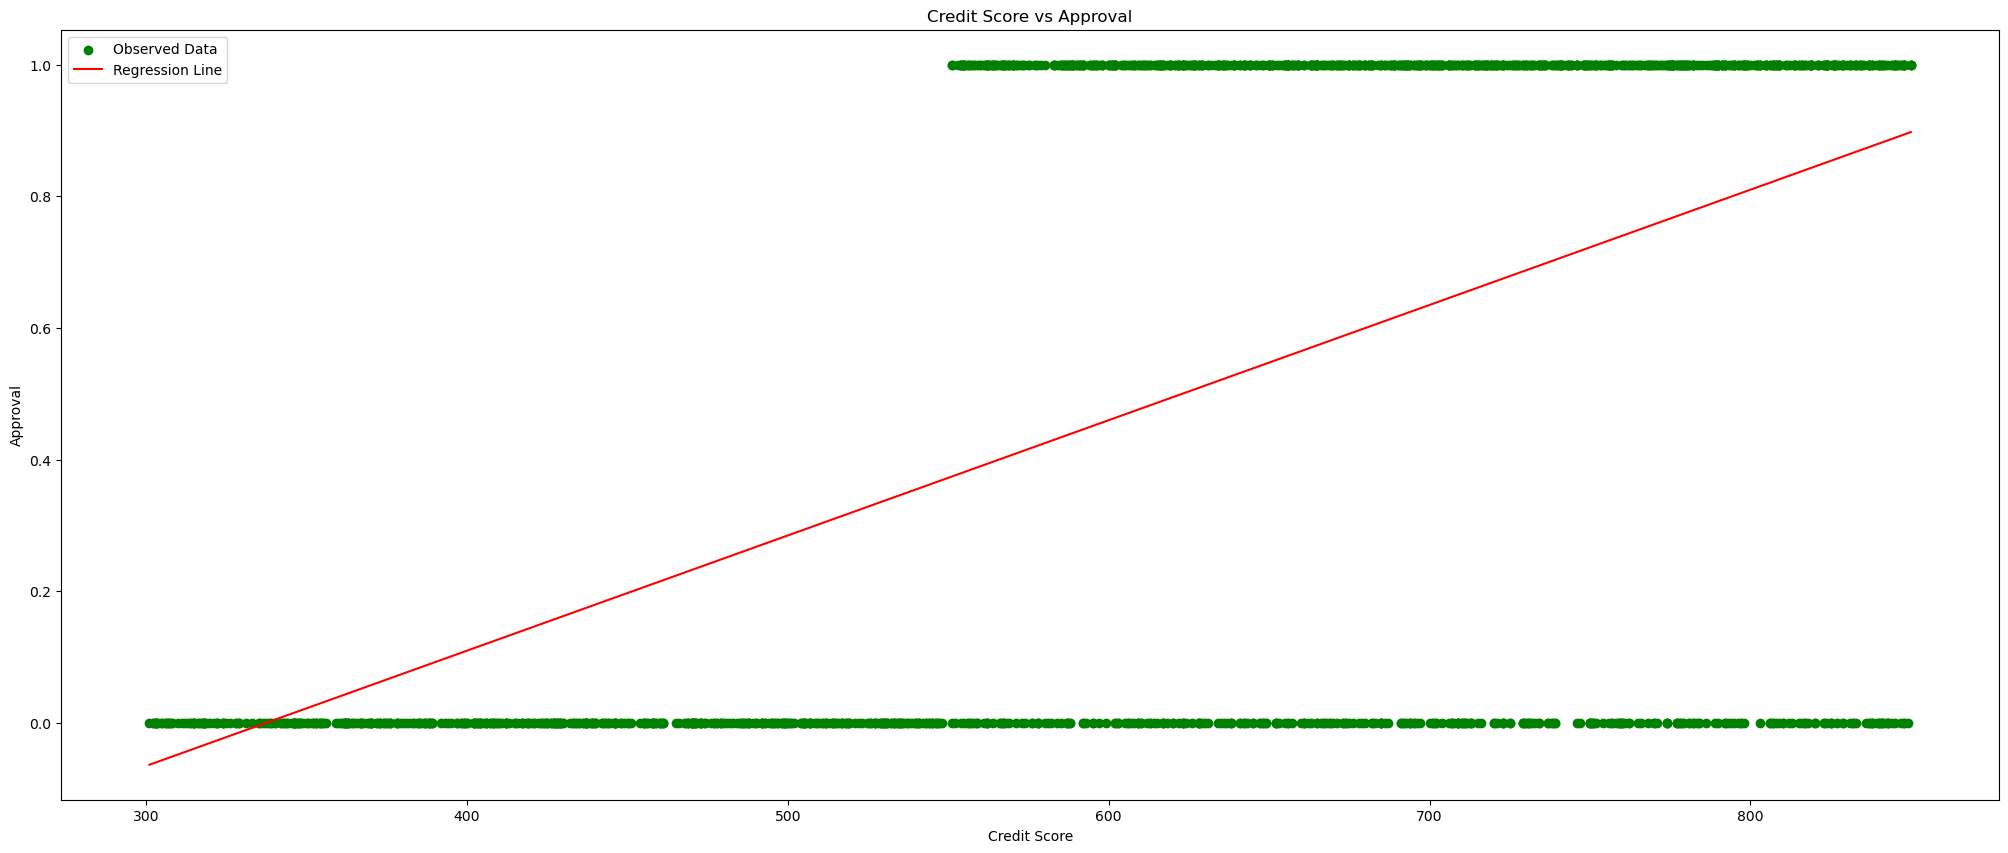

In [236]:
'''This block creates a linear regression model for Credit Score feature against Approval target'''
x = data['Credit_Score'].values.reshape(-1, 1)  
y = data['Approval'].values

#splitting the dataset into training and test sets (80% train, 20% test)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

#create a single linear regression model object
single_regression = LinearRegression()

#fit the model to the training data
single_regression.fit(x_train, y_train)

#apply the model to the test data to get predictions
y_predicted_single = single_regression.predict(x_test)

#model evaluation using RMSE and R-squared
r = numpy.sqrt(mean_squared_error(y_test, y_predicted_single))
r_squared_score = r2_score(y_test, y_predicted_single)

print('The Root Mean Square Error = %.4f' % r)
print('The R-squared = %.4f' % r_squared_score)

#we need to sort x_test and the predicted values for a smooth regression line.
sorted_idx = numpy.argsort(x_test.ravel())
x_test_sorted = x_test[sorted_idx]
y_pred_sorted = y_predicted_single[sorted_idx]

#plot the test data as a scatter plot
matPlot.figure(figsize=(25, 10))
matPlot.scatter(x_test, y_test, color='green', label='Observed Data')
#plot the regression line
matPlot.plot(x_test_sorted, y_pred_sorted, color='red', label='Regression Line')
matPlot.title('Credit Score vs Approval')
matPlot.xlabel('Credit Score')
matPlot.ylabel('Approval')
matPlot.legend()
matPlot.show()

The Root Mean Square Error = 0.4986
The R-squared = 0.0054


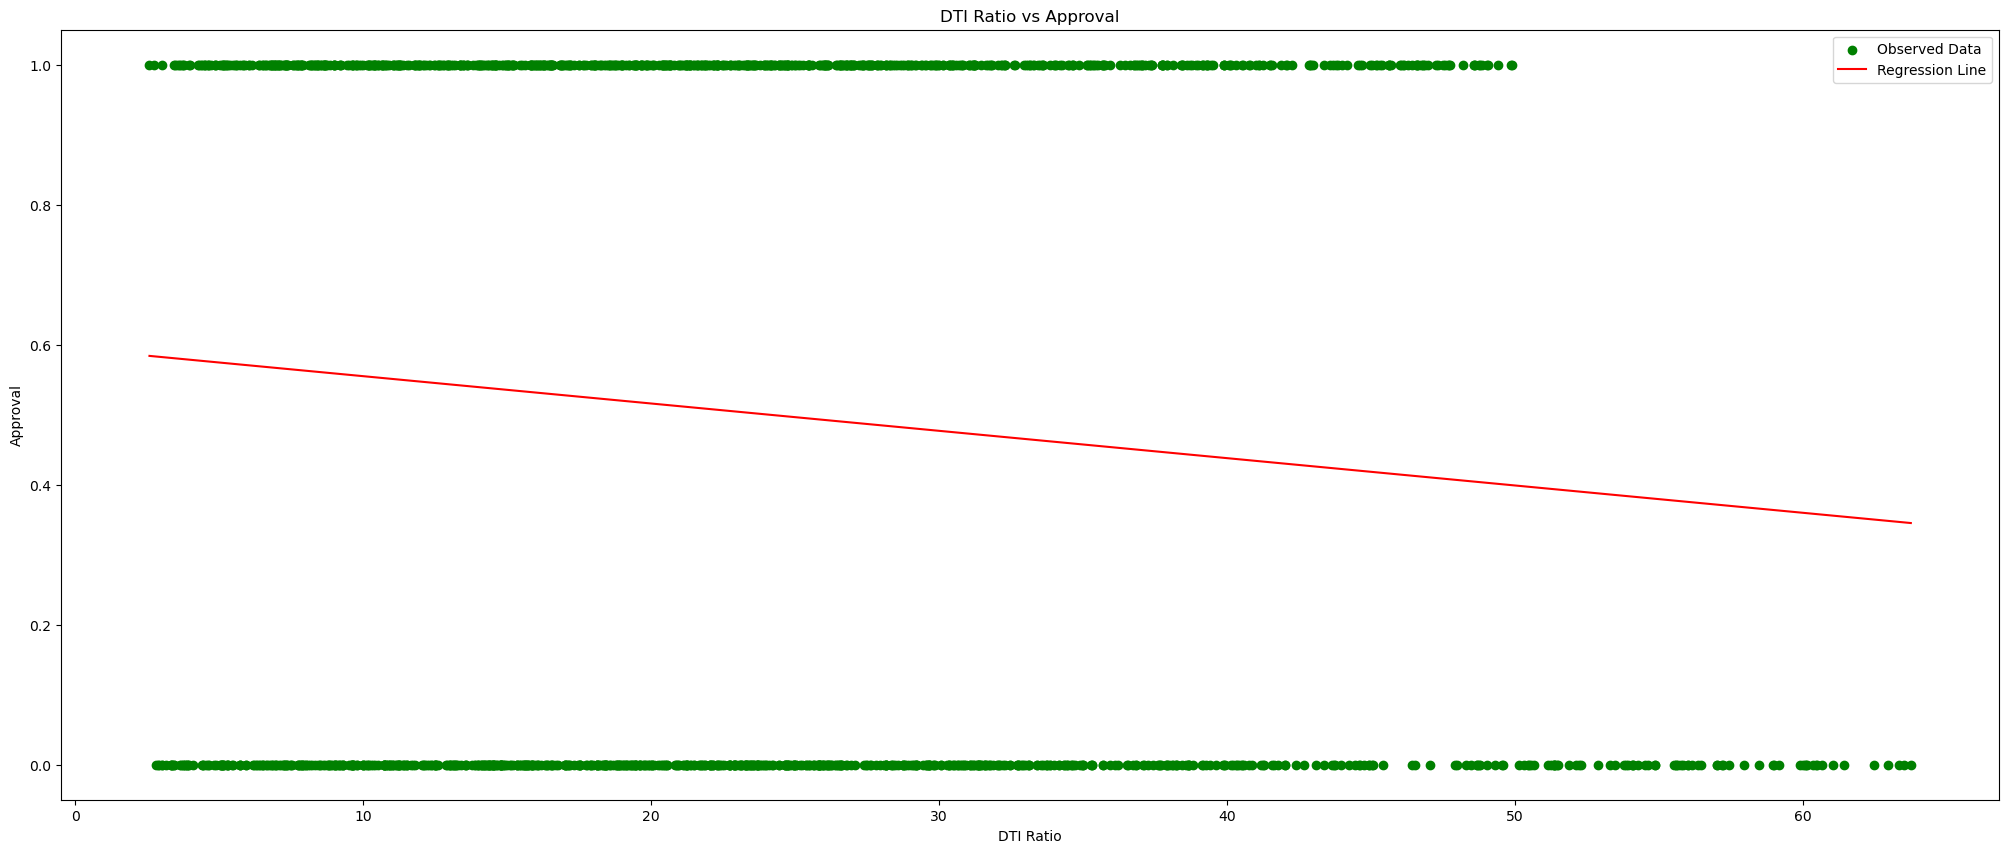

In [237]:
'''This block creates a linear regression model for DTI Ratio feature against Approval target'''
x = data['DTI_Ratio'].values.reshape(-1, 1)  
y = data['Approval'].values

#splitting the dataset into training and test sets (80% train, 20% test)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

#create a single linear regression model object
single_regression = LinearRegression()

#fit the model to the training data
single_regression.fit(x_train, y_train)

#apply the model to the test data to get predictions
y_predicted_single = single_regression.predict(x_test)

#model evaluation using RMSE and R-squared
r = numpy.sqrt(mean_squared_error(y_test, y_predicted_single))
r_squared_score = r2_score(y_test, y_predicted_single)

print('The Root Mean Square Error = %.4f' % r)
print('The R-squared = %.4f' % r_squared_score)

#we need to sort x_test and the predicted values for a smooth regression line.
sorted_idx = numpy.argsort(x_test.ravel())
x_test_sorted = x_test[sorted_idx]
y_pred_sorted = y_predicted_single[sorted_idx]

#plot the test data as a scatter plot
matPlot.figure(figsize=(25, 10))
matPlot.scatter(x_test, y_test, color='green', label='Observed Data')
#plot the regression line
matPlot.plot(x_test_sorted, y_pred_sorted, color='red', label='Regression Line')
matPlot.title('DTI Ratio vs Approval')
matPlot.xlabel('DTI Ratio')
matPlot.ylabel('Approval')
matPlot.legend()
matPlot.show()

The Root Mean Square Error = 0.4892
The R-squared = 0.0422


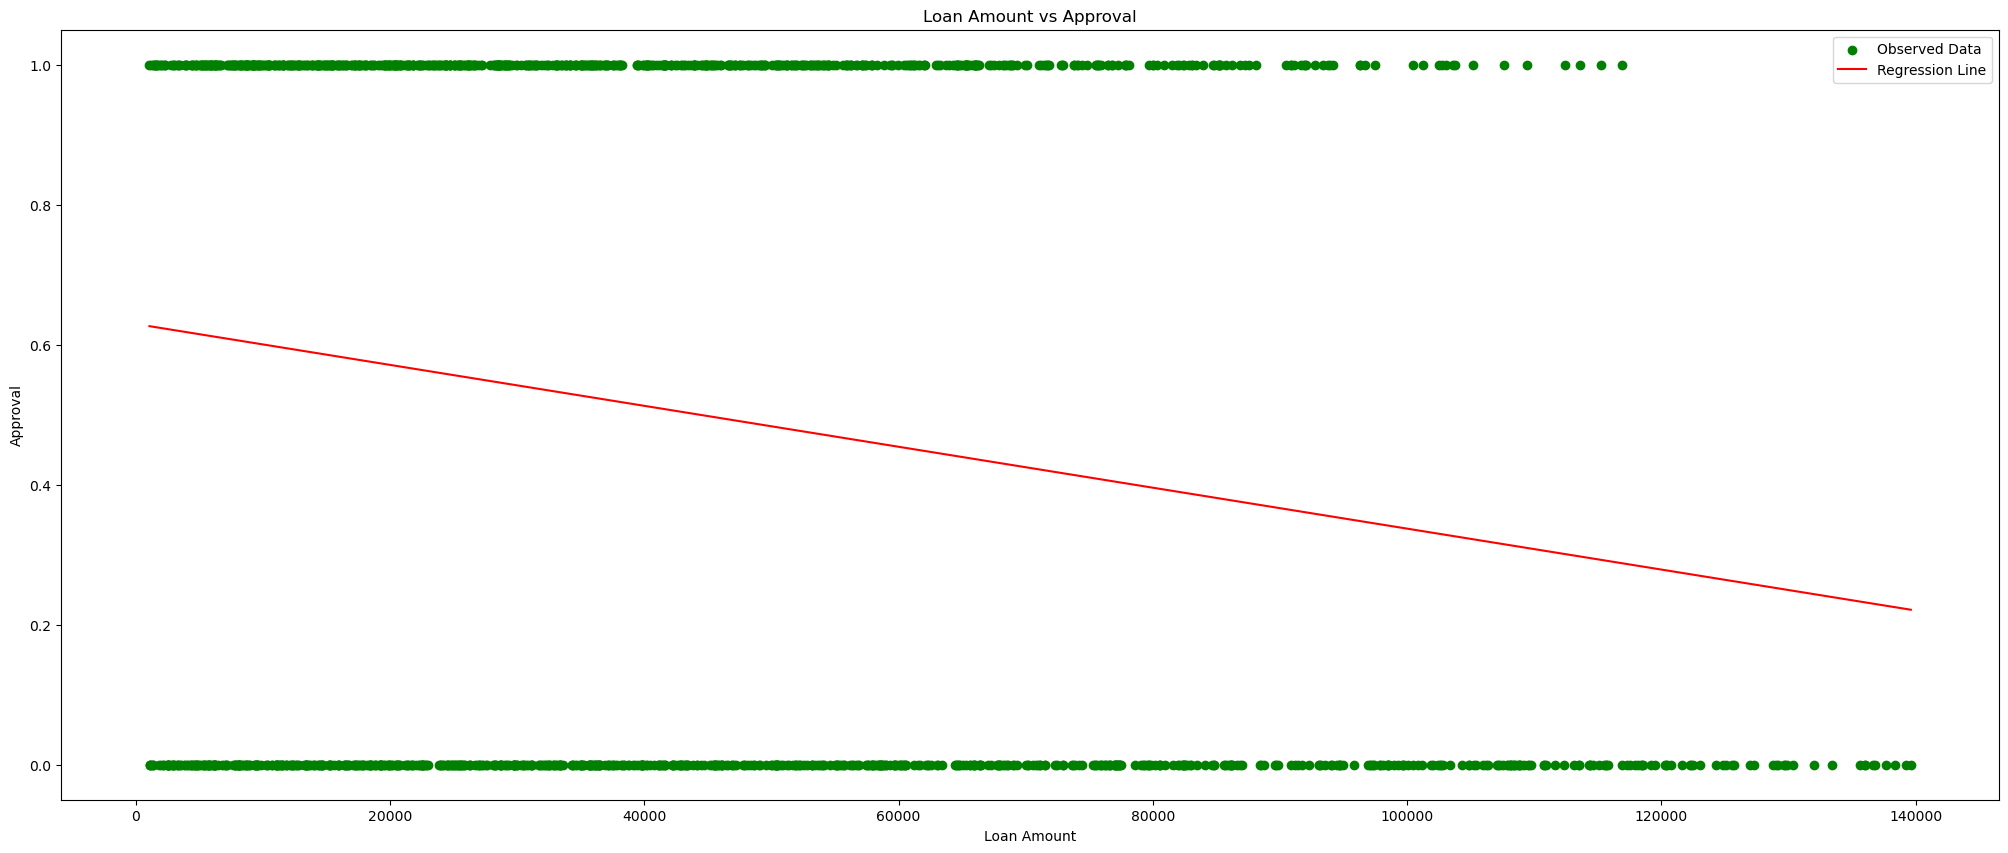

In [239]:
'''This block creates a linear regression model for Loan Amount feature against Approval target'''
x = data['Loan_Amount'].values.reshape(-1, 1)  
y = data['Approval'].values

#splitting the dataset into training and test sets (80% train, 20% test)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

#create a single linear regression model object
single_regression = LinearRegression()

#fit the model to the training data
single_regression.fit(x_train, y_train)

#apply the model to the test data to get predictions
y_predicted_single = single_regression.predict(x_test)

#model evaluation using RMSE and R-squared
r = numpy.sqrt(mean_squared_error(y_test, y_predicted_single))
r_squared_score = r2_score(y_test, y_predicted_single)

print('The Root Mean Square Error = %.4f' % r)
print('The R-squared = %.4f' % r_squared_score)

#we need to sort x_test and the predicted values for a smooth regression line.
sorted_idx = numpy.argsort(x_test.ravel())
x_test_sorted = x_test[sorted_idx]
y_pred_sorted = y_predicted_single[sorted_idx]

#plot the test data as a scatter plot
matPlot.figure(figsize=(25, 10))
matPlot.scatter(x_test, y_test, color='green', label='Observed Data')
#plot the regression line
matPlot.plot(x_test_sorted, y_pred_sorted, color='red', label='Regression Line')
matPlot.title('Loan Amount vs Approval')
matPlot.xlabel('Loan Amount')
matPlot.ylabel('Approval')
matPlot.legend()
matPlot.show()

The Root mean square error = 0.3133
The R-squared = 0.6074


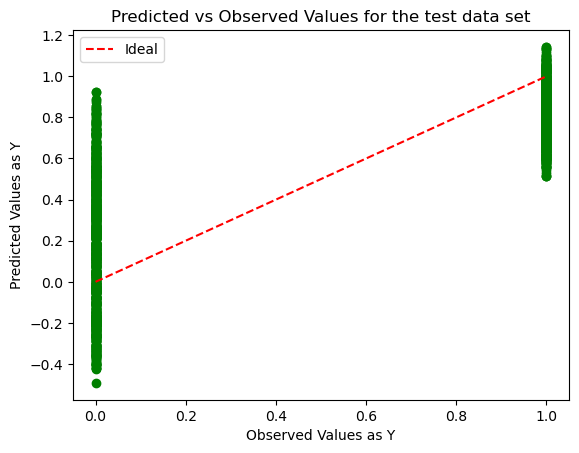

In [240]:
# fitting multiple regression model to training set

import numpy
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

features = data[['Income', 'Credit_Score', 'Loan_Amount', 'DTI_Ratio', 'Employment_Status']].values
target = data['Approval'].values

# Split the dataset into training and test sets
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.20, random_state=42)


# creating a multiple leaner model object
multiple_regression = linear_model.LinearRegression()

# fitting the model to the training data
multiple_regression.fit(x_train, y_train)

# applying the model to the test data
y_predicted = multiple_regression.predict(x_test)

# Evaluating the model
print('The Root mean square error = %.4f' % numpy.sqrt(mean_squared_error(y_test, y_predicted))) 
print('The R-squared = %.4f' % r2_score(y_test, y_predicted))

# comparing the predicted values with the observed values with a line of best-fit
matPlot.scatter(y_test, y_predicted, color='green')
matPlot.title('Predicted vs Observed Values for the test data set')
matPlot.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal')
matPlot.xlabel('Observed Values as Y')
matPlot.ylabel('Predicted Values as Y') 
matPlot.legend()
matPlot.show() 

